# **Impact of COVID-19 on ABC Company Parcel Business**

## **Objectives:**
This analysis examines how COVID-19 impacted ABC Company’s parcel delivery business.

We aim to:
- Evaluate changes in parcel volumes before and during COVID-19
- Identify when the impact began
- Analyze peak season performance
- Identity how revenue was impacted
- Assess customer growth and behavior across customer segments.


This code cell imports essential Python libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib.pyplot`, `seaborn`) and date/time operations (`datetime`). It also configures `seaborn` for better aesthetics and sets the default figure size for `matplotlib` plots. The `%matplotlib inline` command ensures that plots are displayed directly within the notebook output.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from datetime import datetime
                                      #ENSURE TO RELOCATE THE CODE BELOW
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

This code loads the dataset from the CSV file into a pandas DataFrame.


In [3]:
df = pd.read_csv('COVID_Parcel_Business.csv.csv')

## 1. Dataset Overview

The dataset contains customer ID, year, week and parcel volume columns. Each row represents weekly shipments allowing trend and comparison analysis.


In [4]:
print(f"Shape: {df.shape}")
print(f"Years: {sorted(df['THE_YEAR'].unique())}")
print(f"Unique Customers: {df['FakeCustomerID'].nunique():,}")
df

Shape: (190719, 4)
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Unique Customers: 1,061


,FakeCustomerID,THE_YEAR,THE_WEEK,VOLUME
0,718117,2021,1,8
1,718117,2020,7,257
2,718117,2019,39,141
3,718117,2018,1,14
4,718117,2021,2,192
...,...,...,...,...
190714,228893,2019,13,30
190715,228893,2019,38,122
190716,228893,2019,48,99
190717,228893,2019,20,61



## 2.(a) Perfroming Descriptive Statistics on Dataset  

This section performs a basic descriptive statistics of our dataset. It gives us the count, mean, standard deviation, min, max and quartile values for FakeCustomerID, THE_YEAR, THE_WEEK and VOLUME columns. This gives a quick overview of the data's distribution.

In [ ]:
df.describe()

,FakeCustomerID,THE_YEAR,THE_WEEK,VOLUME
count,190719.000000,190719.000000,190719.000000,190719.000000
mean,541440.234963,2019.395220,25.676377,1174.911519
std,264861.365663,1.068845,14.722539,11586.730666
min,100771.000000,2018.000000,1.000000,1.000000
25%,308930.000000,2018.000000,13.000000,25.000000
50%,529707.000000,2019.000000,25.000000,58.000000
75%,778800.000000,2020.000000,38.000000,162.000000
max,999362.000000,2021.000000,53.000000,640590.000000



## 3. Industry Standard Growth Rate (ISGR)

We are now calculating the Industry Standard Growth Rate (ISGR) based on pre-COVID parcel volumes. This will provide a baseline for normal business growth, allowing us to identify COVID-driven growth later.

The pre-COVID parcel volume increased from **13,122,816 in 2019** to **14,619,017 in 2020**, resulting in an ISGR of **11.4%**.

This indicates that the business was already experiencing steady growth prior to the COVID-19 pandemic.

The ISGR serves as a baseline for normal business growth. Any customer or segment with growth exceeding **11.4%** during the COVID period can be considered to have experienced additional COVID-driven growth.

This distinction ensures that increases in parcel volumes are correctly attributed to the impact of the pandemic rather than normal business expansion.

In [5]:
# Pre-COVID periods (Weeks 1–15)
vol_2019_pre = df[(df['THE_YEAR']==2019) & (df['THE_WEEK']<=15)]['VOLUME'].sum()
vol_2020_pre = df[(df['THE_YEAR']==2020) & (df['THE_WEEK']<=15)]['VOLUME'].sum()

# ISGR calculation
ISGR = ((vol_2020_pre - vol_2019_pre) / vol_2019_pre) * 100

print("Pre-COVID Volume 2019 - (W1-W15):", f"{vol_2019_pre:,}")
print("Pre-COVID Volume 2020 - (W1-W15):", f"{vol_2020_pre:,}")
print("ISGR (%):", round(ISGR, 2))

Pre-COVID Volume 2019 - (W1-W15): 13,122,816
Pre-COVID Volume 2020 - (W1-W15): 14,619,017
ISGR (%): 11.4



## 4. Annual Parcel Volume Analysis and Year-over-Year Change

This section provides the total parcel volume for each year and calculates the Year-over-Year (YoY) percentage change to highlight growth trends in a bit to exploring our dataset.  

This shows a substantial growth in parcel volume in 2020, likely influenced by the COVID-19 pandemic, followed by a decrease in 2021, possibly indicating a normalization of demand.

Based on the annual parcel volume analysis, it's clear that parcel volumes increased significantly in 2020, indicating a strong growth in demand driven by COVID-19 and the expansion of e-commerce.

In [10]:
yearly_volume = df.groupby('THE_YEAR')['VOLUME'].sum().reset_index()
yearly_volume.rename(columns={'VOLUME': 'Total_Volume'}, inplace=True)

# Calculate Year-over-Year Change
yearly_volume['YoY_Change'] = yearly_volume['Total_Volume'].pct_change() * 100

print("Annual Total Volume and YoY Change:")
display(yearly_volume.round(2))

Annual Total Volume and YoY Change:


,THE_YEAR,Total_Volume,YoY_Change
0,2018,49099478,NaN
1,2019,52823114,7.58
2,2020,73475690,39.10
3,2021,48679668,-33.75


## 5. Customer Segmentation (Customer Groups Information)

Customers are segmented based on Volume by Customer Segment (2019 vs 2020). This analysis compares parcel volumes across customer segments to assess the impact of COVID-19 in 2019 and 2020.  

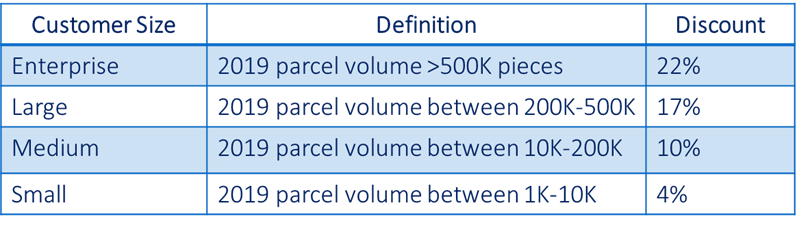



Customer Group Distribution Comparison:
             2019  2020
Small         860   681
Medium        174   234
Large          15    22
Enterprise     12    14
Micro/Other     0    95

Customer Movement Matrix:
Group2020   Churned  Enterprise  Large  Medium  Micro/Other  Small
Group2019                                                         
Enterprise        0          12      0       0            0      0
Large             0           2     11       2            0      0
Medium            1           0     11     137            0     25
Small            14           0      0      95           95    656


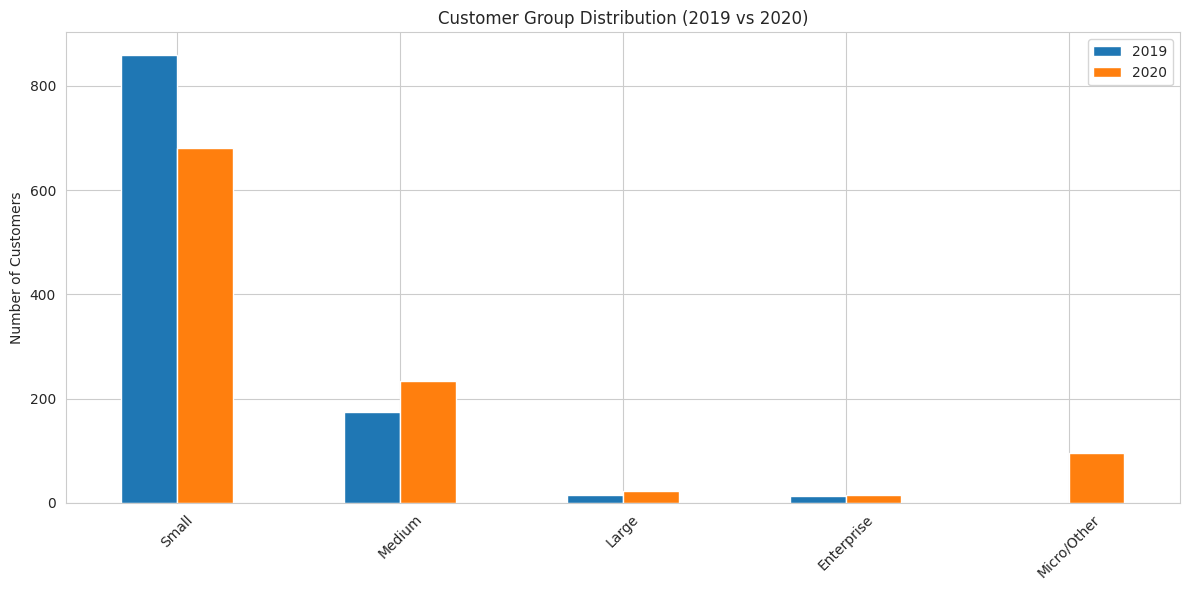

In [11]:

# --- Step 1: Aggregate volumes ---
vol_2019 = df[df['THE_YEAR'] == 2019].groupby('FakeCustomerID')['VOLUME'].sum().reset_index()
vol_2019.columns = ['FakeCustomerID', 'Vol2019']

vol_2020 = df[df['THE_YEAR'] == 2020].groupby('FakeCustomerID')['VOLUME'].sum().reset_index()
vol_2020.columns = ['FakeCustomerID', 'Vol2020']

# Step 2: Define grouping logic
def assign_group(v):
    if v > 500_000:
        return 'Enterprise'
    elif v >= 200_000:
        return 'Large'
    elif v >= 10_000:
        return 'Medium'
    elif v >= 1_000:
        return 'Small'
    else:
        return 'Micro/Other'

# Apply grouping
vol_2019['Group2019'] = vol_2019['Vol2019'].apply(assign_group)
vol_2020['Group2020'] = vol_2020['Vol2020'].apply(assign_group)

#  Step 3: Distribution comparison
dist_2019 = vol_2019['Group2019'].value_counts().rename("2019")
dist_2020 = vol_2020['Group2020'].value_counts().rename("2020")

comparison = pd.concat([dist_2019, dist_2020], axis=1).fillna(0).astype(int)

print("\nCustomer Group Distribution Comparison:")
print(comparison)

#Step 4: Movement / Transition Analysis
movement = pd.merge(vol_2019[['FakeCustomerID', 'Group2019']],
                    vol_2020[['FakeCustomerID', 'Group2020']],
                    on='FakeCustomerID',
                    how='outer')

movement['Group2019'] = movement['Group2019'].fillna('New')
movement['Group2020'] = movement['Group2020'].fillna('Churned')

transition_matrix = pd.crosstab(movement['Group2019'], movement['Group2020'])

print("\nCustomer Movement Matrix:")
print(transition_matrix)


comparison.plot(kind='bar')
plt.title("Customer Group Distribution (2019 vs 2020)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Pre-COVID vs COVID Comparison  

- **Pre-COVID Period: Week 1 to Week 11, 2020**  

- **COVID Observation Period: Week 12 to Week 53, 2020**

Please note that a national emergency was declared in Canadan on March 13, 2020 which was on Week 11. The implementation of lockdowns was effected in Week 12 (March 16–22, 2020) by all the Canadian provinces.  

Insight:
Parcel volumes began experiencing a significant growth during COVID confirming increased delivery demand across Canada.

In [12]:
COVID_WEEK_ANALYSIS = 12

# Weekly volumes 2019 vs 2020
weekly = df[df['THE_YEAR'].isin([2019,2020])].groupby(['THE_YEAR','THE_WEEK'])['VOLUME'].sum().reset_index()
w2019 = weekly[weekly['THE_YEAR']==2019].set_index('THE_WEEK')['VOLUME']
w2020 = weekly[weekly['THE_YEAR']==2020].set_index('THE_WEEK')['VOLUME']

# Print weeks around COVID onset
print('Weekly Volume: 2019 vs 2020 (around COVID onset)')
print(f'{"Week":<6} {"2019":>12} {"2020":>12} {"Change":>10}')
print('-'*45)
for w in range(8, 22):
    v19 = w2019.get(w, 0)
    v20 = w2020.get(w, 0)
    chg = (v20-v19)/v19*100 if v19 else 0
    flag = ' ← COVID onset' if w == COVID_WEEK_ANALYSIS else ''
    print(f'  W{w:<4} {v19:>12,.0f} {v20:>12,.0f} {chg:>+9.1f}%{flag}')

Weekly Volume: 2019 vs 2020 (around COVID onset)
Week           2019         2020     Change
---------------------------------------------
  W8         764,078      882,633     +15.5%
  W9         803,745      903,362     +12.4%
  W10        792,805      891,398     +12.4%
  W11        879,574      887,335      +0.9%
  W12        864,583      967,436     +11.9% ← COVID onset
  W13        853,762    1,084,829     +27.1%
  W14        817,979    1,346,802     +64.6%
  W15        874,088    1,480,147     +69.3%
  W16        879,169    2,003,866    +127.9%
  W17        912,863    1,914,740    +109.8%
  W18      1,059,240    1,964,582     +85.5%
  W19      1,102,598    2,016,316     +82.9%
  W20        951,212    2,048,931    +115.4%
  W21        874,423    1,842,820    +110.7%


## 6. Weekly Trend Analysis

### Insight:
Volumes begin diverging around Week 12, aligning with COVID lockdowns.
This indicates a structural shift in customer behavior.


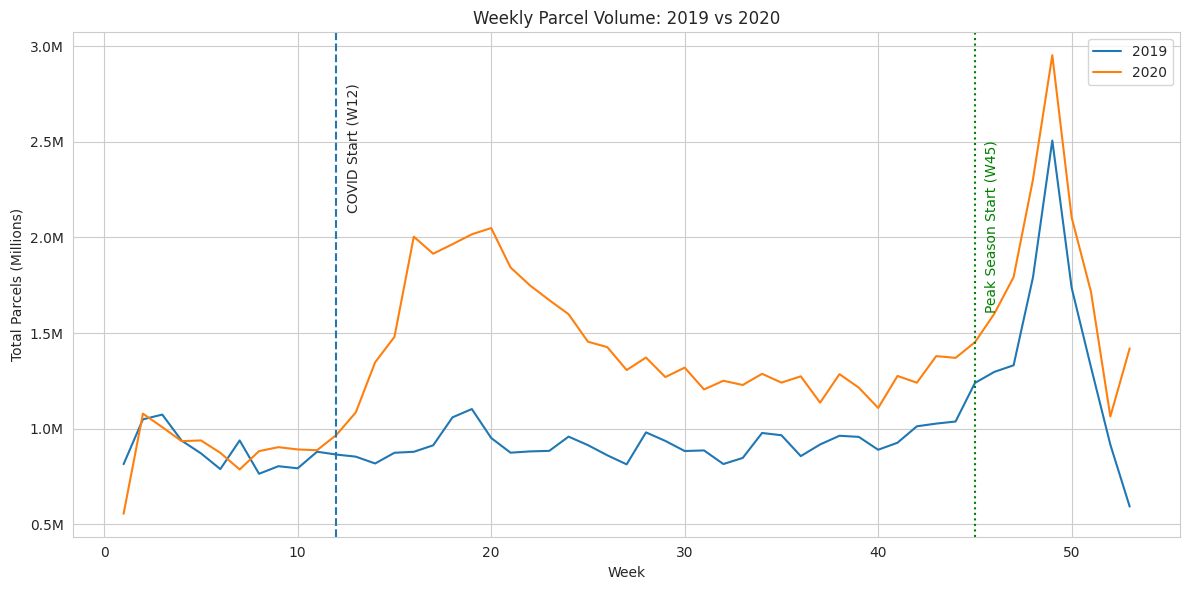

In [13]:

#Filter only 2019 and 2020
df_filtered = df[df['THE_YEAR'].isin([2019, 2020])]

#  Aggregate weekly volume
weekly = df_filtered.groupby(['THE_YEAR', 'THE_WEEK'])['VOLUME'].sum().reset_index()

plt.figure()
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 4)
%matplotlib inline

# Plot only 2019 and 2020
for year in [2019, 2020]:
    temp = weekly[weekly['THE_YEAR'] == year].sort_values('THE_WEEK')
    plt.plot(temp['THE_WEEK'], temp['VOLUME'], label=str(year))

# Format Y-axis to Millions
def millions(x, pos):
    return f'{x/1_000_000:.1f}M'

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

# Get max for positioning
y_max = weekly['VOLUME'].max()

#  COVID marker
plt.axvline(x=12, linestyle='--')
plt.text(12 + 0.5, y_max * 0.95, 'COVID Start (W12)', rotation=90,
         verticalalignment='top')

# Peak Season marker
plt.axvline(x=45, color='green', linestyle=':')
plt.text(45 + 0.5, y_max * 0.85, 'Peak Season Start (W45)', rotation=90,
         color='green', verticalalignment='top')

#  Labels
plt.title("Weekly Parcel Volume: 2019 vs 2020")
plt.xlabel("Week")
plt.ylabel("Total Parcels (Millions)")
plt.legend()

plt.tight_layout()
plt.show()

## 7. Peak Season Analysis

### Insight:
2020 peak season outperformed 2019 driven by increased online shopping.


## 7. (a) Customer Segment Analysis  

This code block aggregates customer-level parcel volumes for different periods: 2019, early 2020 (weeks 1-10), the COVID observation period (from week 11 in 2020) and total 2020. It then merges these volumes into a central `cust` DataFrame.

Subsequently, it classifies customers into groups (Enterprise, Large, Medium, Small) based on their 2019 total volume. This process prepares the data for analyzing customer behavior and segment-specific impacts of COVID-19.

In [14]:
covid_start_week = 11
cust = df.groupby('FakeCustomerID').agg({
    'VOLUME': 'sum'
}).rename(columns={'VOLUME': 'Total_Volume'}).reset_index()

# Volume by key periods
vol_2019 = df[df['THE_YEAR']==2019].groupby('FakeCustomerID')['VOLUME'].sum().rename('Vol_2019')
vol_early2020 = df[(df['THE_YEAR']==2020) & (df['THE_WEEK'] <= 10)].groupby('FakeCustomerID')['VOLUME'].sum().rename('Early2020')
vol_covid = df[(df['THE_YEAR']==2020) & (df['THE_WEEK'] >= covid_start_week)].groupby('FakeCustomerID')['VOLUME'].sum().rename('Covid_Vol')
vol_2020_total = df[df['THE_YEAR']==2020].groupby('FakeCustomerID')['VOLUME'].sum().rename('Vol_2020')

cust = cust.merge(vol_2019, on='FakeCustomerID', how='left').fillna(0)
cust = cust.merge(vol_early2020, on='FakeCustomerID', how='left').fillna(0)
cust = cust.merge(vol_covid, on='FakeCustomerID', how='left').fillna(0)
cust = cust.merge(vol_2020_total, on='FakeCustomerID', how='left').fillna(0)
cust

,FakeCustomerID,Total_Volume,Vol_2019,Early2020,Covid_Vol,Vol_2020
0,100771,6252,1816,347.0,1442.0,1789.0
1,102180,20553,5222,423.0,4394.0,4817.0
2,102643,8164,2670,522.0,1181.0,1703.0
3,102750,2747,1013,184.0,221.0,405.0
4,103308,326088,90140,16623.0,87077.0,103700.0
...,...,...,...,...,...,...
1056,994361,7817,2608,543.0,1115.0,1658.0
1057,994762,2750,1073,121.0,229.0,350.0
1058,995173,11041,1632,115.0,4805.0,4920.0
1059,999141,12577,3364,624.0,2995.0,3619.0


## 7. (i) Impact by Customer Group

Enterprise customers dominate total volume despite being few in number, while Small customers exhibit the fastest growth rate.

The sharp increase in 2020 across all segments confirms that COVID-19 created a structural shift in demand, rather than a temporary fluctuation.

The decline in 2021 reflects normalization rather than a loss in business strength.

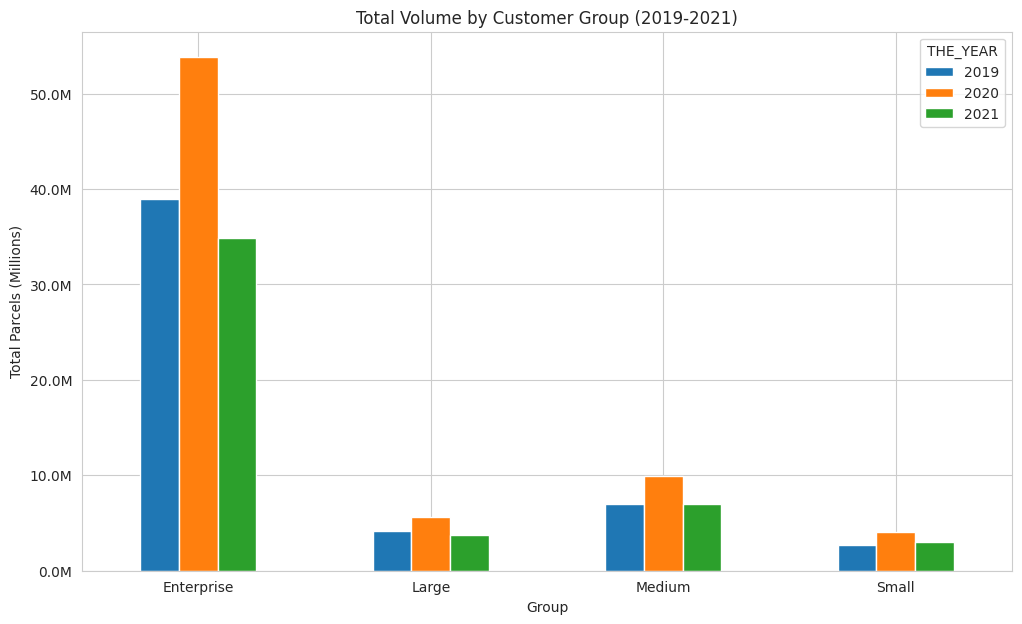

In [15]:
# Step 1: Create customer groups from 2019 volume
cust_2019 = df[df['THE_YEAR']==2019] \
    .groupby('FakeCustomerID')['VOLUME'].sum().reset_index()

cust_2019.columns = ['FakeCustomerID','volume_2019']

def group_customer(x):
    if x > 500000:
        return 'Enterprise'
    elif x > 200000:
        return 'Large'
    elif x > 10000:
        return 'Medium'
    else:
        return 'Small'

cust_2019['Group'] = cust_2019['volume_2019'].apply(group_customer)

# Merge 'Group' into cust
if 'Group' not in cust.columns:
    cust = cust.merge(
        cust_2019[['FakeCustomerID','Group']],
        on='FakeCustomerID',
        how='left'
    )

group_vol = df.merge(cust[['FakeCustomerID', 'Group']], on='FakeCustomerID')

group_year_vol = group_vol[
    group_vol['THE_YEAR'].isin([2019, 2020, 2021])
].groupby(['Group', 'THE_YEAR'], observed=False)['VOLUME'].sum().unstack()

# --- Plot ---
ax = group_year_vol.plot(kind='bar', figsize=(12,7))

# --- Format Y-axis to Millions ---
def millions(x, pos):
    return f'{x/1_000_000:.1f}M'

ax.yaxis.set_major_formatter(FuncFormatter(millions))

plt.title('Total Volume by Customer Group (2019-2021)')
plt.ylabel('Total Parcels (Millions)')
plt.xticks(rotation=0)

plt.savefig('volume_by_group.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. (ii) Interpretation of Customer-Level Metrics  

The table shows parcel volumes for each customer across pre-COVID and COVID periods.

### Key Insights:
- Many customers exhibit higher parcel volumes during the COVID period compared to earlier periods, indicating increased demand for delivery services.
- For several customers, the majority of their 2020 volume is concentrated during the COVID period, confirming that growth was driven by the pandemic.
- However, not all customers experienced growth—some show lower volumes during COVID, indicating that the impact was uneven across different businesses.
- Larger customers tend to maintain high and stable volumes, while smaller customers show more variability.

Customers in the COVID observation period (W12–53, 2020) are classified as:
- **High Growth**: Growth > ISGR during COVID period
- **Stable**: 0% to ISGR growth during COVID period  
- **Declining**: Negative growth
- **Lost**: Had volume in 2019 but zero during COVID period

### Business Interpretation:
Overall, COVID-19 had a strong positive impact on parcel demand, but its effects varied across customers.

This variation highlights the importance of customer segmentation to distinguish between high-growth, stable, and declining businesses during the pandemic.

In [17]:
# Ensure threshold is defined
ISGR = 20  # example: 20% growth threshold

COVID_WEEK = 12

# Base: include ALL customers
cust_df = pd.DataFrame(df['FakeCustomerID'].unique(), columns=['FakeCustomerID'])

# Volume calculations
vol_2019 = df[df['THE_YEAR']==2019].groupby('FakeCustomerID')['VOLUME'].sum().rename('Vol2019')
covid_vol = df[(df['THE_YEAR']==2020) & (df['THE_WEEK']>=COVID_WEEK)].groupby('FakeCustomerID')['VOLUME'].sum().rename('CovidVol2020')
same_period_2019 = df[(df['THE_YEAR']==2019) & (df['THE_WEEK']>=COVID_WEEK)].groupby('FakeCustomerID')['VOLUME'].sum().rename('SamePeriod2019')
pre_2019_vol = df[(df['THE_YEAR']==2019) & (df['THE_WEEK']<COVID_WEEK)].groupby('FakeCustomerID')['VOLUME'].sum().rename('PreCovidVol2019')

# Merge all metrics
cust_df = cust_df.merge(vol_2019, on='FakeCustomerID', how='left')
cust_df = cust_df.merge(covid_vol, on='FakeCustomerID', how='left')
cust_df = cust_df.merge(same_period_2019, on='FakeCustomerID', how='left')
cust_df = cust_df.merge(pre_2019_vol, on='FakeCustomerID', how='left')

#  Fill missing values
cust_df[['Vol2019','CovidVol2020','SamePeriod2019','PreCovidVol2019']] = \
    cust_df[['Vol2019','CovidVol2020','SamePeriod2019','PreCovidVol2019']].fillna(0)

#  Classification logic (FIXED)
def classify(row):
    had_vol_before = (row['Vol2019'] > 0) or (row['PreCovidVol2019'] > 0)
    has_covid_vol = row['CovidVol2020'] > 0

    # New customer (no history, appears during COVID)
    if not had_vol_before and has_covid_vol:
        return 'New'

    # Lost customer (had history, disappears during COVID)
    if had_vol_before and not has_covid_vol:
        return 'Lost'

    # Handle zero baseline safely
    if row['SamePeriod2019'] == 0:
        return 'Stable'  # or 'Undefined' depending on preference

    growth = (row['CovidVol2020'] - row['SamePeriod2019']) / row['SamePeriod2019'] * 100

    if growth > ISGR:
        return 'High Growth'
    elif growth >= 0:
        return 'Stable'
    else:
        return 'Declining'

cust_df['Status'] = cust_df.apply(classify, axis=1)

# OPTIONAL: Add Customer Group (from 2019)
def assign_group(v):
    if v > 500000:
        return 'Enterprise'
    elif v >= 200000:
        return 'Large'
    elif v >= 10000:
        return 'Medium'
    elif v >= 1000:
        return 'Small'
    else:
        return 'Micro/Other'

cust_df['CustomerGroup'] = cust_df['Vol2019'].apply(assign_group)

# Final aggregation
result = cust_df.groupby(['CustomerGroup','Status']).size().unstack(fill_value=0)
pct = result.div(result.sum(axis=1), axis=0) * 100

print('=== Count by Group & Status ===')
print(result)

print('\n=== % Breakdown by Group ===')
print(pct.round(1))

=== Count by Group & Status ===
Status         Declining  High Growth  Lost  Stable
CustomerGroup                                      
Enterprise             3            7     0       2
Large                  2            9     0       4
Medium                66           78     1      29
Small                299          441    25      95

=== % Breakdown by Group ===
Status         Declining  High Growth  Lost  Stable
CustomerGroup                                      
Enterprise          25.0         58.3   0.0    16.7
Large               13.3         60.0   0.0    26.7
Medium              37.9         44.8   0.6    16.7
Small               34.8         51.3   2.9    11.0


## 7. (iii) Customer Status Chart by Group  

This code block generates a stacked bar chart to visualize the distribution of customer statuses (High Growth, Stable, Declining, Lost, New) within each customer segment (Enterprise, Large, Medium, Small). It uses a colorblind-safe palette for better accessibility and displays percentages on the bars to clearly show the proportion of each status within a segment. The chart provides a clear visual summary of how different customer groups were impacted during the COVID observation period.

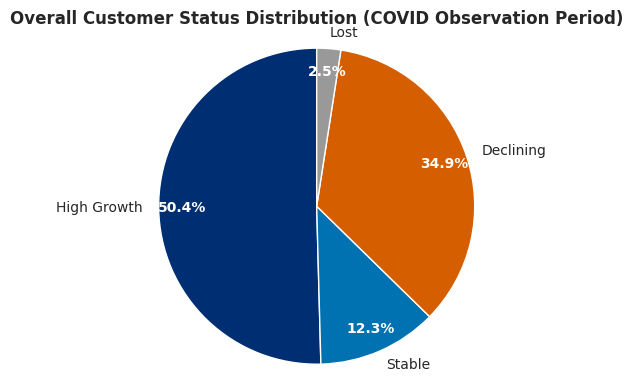

In [36]:
colors = {
    'High Growth': '#002E73',   # green
    'Stable': '#0072B2',        # blue
    'Declining': '#D55E00',     # orange-red
    'Lost': '#999999',          # grey
    'New': '#CC79A7'            # purple
}

# Status order for consistent coloring and display
status_order = ['High Growth','Stable','Declining','Lost','New']

# Assuming 'result' DataFrame is available from the previous cell
# 'result' contains counts of customers by CustomerGroup and Status

# Calculate total counts for each status across all groups
# We'll use cust_df['Status'].value_counts() for the most accurate overall status counts
# as 'result' might not contain 'New' if no customers were classified as such.
# However, to be consistent with the original data flow, let's derive from `result` first
# and then ensure we have all statuses from `status_order`.

# Calculate total counts for each status across all customer groups from the 'result' DataFrame
total_status_counts = result.sum(axis=0)

# Convert to percentages for the pie chart
overall_status_percentages = (total_status_counts / total_status_counts.sum()) * 100

# Reindex to include all statuses from status_order and ensure consistent ordering
overall_status_percentages = overall_status_percentages.reindex(status_order, fill_value=0)

# Filter out statuses with 0% for cleaner pie chart if desired, or keep to show all potential categories.
# Keeping for now, if a slice is 0, it won't be visible anyway.
overall_status_percentages = overall_status_percentages[overall_status_percentages > 0]

# Plot Pie Chart
fig, ax = plt.subplots(figsize=(5, 4))

pie_colors = [colors.get(s, '#333333') for s in overall_status_percentages.index]

wedges, texts, autotexts = ax.pie(overall_status_percentages,
                                  labels=overall_status_percentages.index,
                                  autopct='%1.1f%%',
                                  colors=pie_colors,
                                  startangle=90,
                                  pctdistance=0.85,
                                  wedgeprops={'edgecolor': 'white'})

# Enhance visibility of percentage labels
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

# Ensure labels are clear
for text in texts:
    text.set_fontsize(10)

ax.set_title('Overall Customer Status Distribution (COVID Observation Period)', fontweight='bold')
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.savefig('chart_customer_status_pie.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. (b) Annual Parcel Volume Analysis  

### Insight:
Parcel volumes increased significantly in 2020 showing strong demand growth due to COVID-19 and e-commerce expansion compared to 2019.

Volume in Peak Season 2019: 15,372,691
Volume in Peak Season 2020: 19,442,907
Change: +26.5%


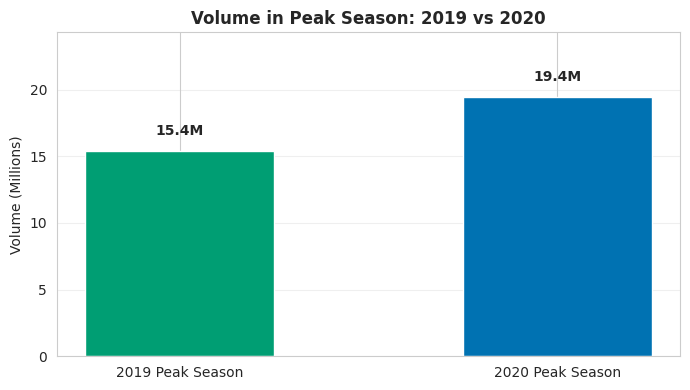

In [18]:
#  Define peak season correctly (cross-year handled clearly)
peak19 = df
    ((df['THE_YEAR'] == 2019) & (df['THE_WEEK'] >= 45)) |
    ((df['THE_YEAR'] == 2020) & (df['THE_WEEK'] <= 3))
]['VOLUME'].sum()

peak20 = df[
    ((df['THE_YEAR'] == 2020) & (df['THE_WEEK'] >= 45)) |
    ((df['THE_YEAR'] == 2021) & (df['THE_WEEK'] <= 3))
]['VOLUME'].sum()

# Safe % change
change = ((peak20 - peak19) / peak19 * 100) if peak19 != 0 else 0

print(f'Volume in Peak Season 2019: {peak19:,.0f}')
print(f'Volume in Peak Season 2020: {peak20:,.0f}')
print(f'Change: {change:+.1f}%')

#  Prepare values
values = [peak19 / 1e6, peak20 / 1e6]
labels = ['2019 Peak Season', '2020 Peak Season']

#  Plot
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    labels,
    values,
    color=['#009E73', '#0072B2'],  # clean, distinct palette
    width=0.5
)

#  Dynamic scaling
max_val = max(values)
offset = max_val * 0.05

# Bar labels (well positioned)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f'{bar.get_height():.1f}M',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Formatting
ax.set_ylabel('Volume (Millions)')
ax.set_title('Volume in Peak Season: 2019 vs 2020', fontweight='bold')
ax.set_ylim(0, max_val * 1.25)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_peak_season.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 # New vs Lost Customers by Group

               New Customers %  Lost Customers %
CustomerGroup                                   
Enterprise                 0.0          0.000000
Large                      0.0          0.000000
Medium                     0.0          0.574713
Small                      0.0          2.906977


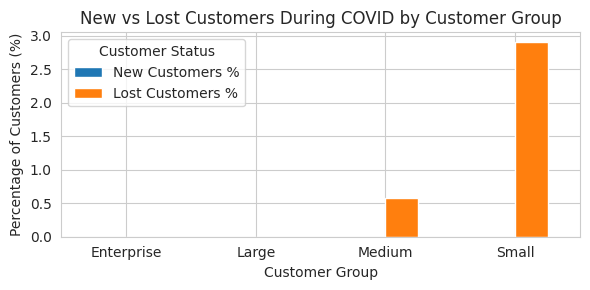

In [24]:

# Define periods
covid_df = df[(df['THE_YEAR'] == 2020) & (df['THE_WEEK'] >= 12)]
df_2019 = df[df['THE_YEAR'] == 2019]

# Customer lists
customers_2019 = set(df_2019['FakeCustomerID'].unique())
customers_covid = set(covid_df['FakeCustomerID'].unique())

# New and lost customers
new_customers = customers_covid - customers_2019
lost_customers = customers_2019 - customers_covid

# Customer group mapping - Corrected to use cust_df
group_map = cust_df.set_index('FakeCustomerID')['CustomerGroup']

# Total customers by group
total_group = group_map.value_counts()

# New customers by group
new_group = group_map.loc[list(new_customers)].value_counts()

# Lost customers by group
lost_group = group_map.loc[list(lost_customers)].value_counts()

# Percent calculation
new_percent = (new_group / total_group * 100).fillna(0)
lost_percent = (lost_group / total_group * 100).fillna(0)

# Combine into one table
new_lost_compare = pd.DataFrame({
    'New Customers %': new_percent,
    'Lost Customers %': lost_percent
}).fillna(0)

print(new_lost_compare)

# Plot comparison chart with reduced figsize
new_lost_compare.plot(kind='bar', figsize=(6, 3))

plt.title('New vs Lost Customers During COVID by Customer Group')
plt.xlabel('Customer Group')
plt.ylabel('Percentage of Customers (%)')
plt.xticks(rotation=0)
plt.legend(title='Customer Status')
plt.tight_layout()
plt.show()

#  Overall impact of COVID on volumes and revenue by customer group

In [26]:

price_per_parcel = 22

# Define comparison periods
# Pre-COVID baseline = 2019 full year
pre_covid = df[df['THE_YEAR'] == 2019]

# COVID period = 2020 full year
covid = df[df['THE_YEAR'] == 2020]

# Get customer group mapping from cust_df
customer_group_map = cust_df[['FakeCustomerID', 'CustomerGroup']].drop_duplicates()

# Merge customer group into pre_covid and covid dataframes
pre_covid_grouped = pre_covid.merge(customer_group_map, on='FakeCustomerID', how='left')
covid_grouped = covid.merge(customer_group_map, on='FakeCustomerID', how='left')

# Total volume by customer group
pre_volume = pre_covid_grouped.groupby('CustomerGroup')['VOLUME'].sum()
covid_volume = covid_grouped.groupby('CustomerGroup')['VOLUME'].sum()

# Combine results
impact_group = pd.DataFrame({
    '2019 Volume': pre_volume,
    '2020 Volume': covid_volume
}).fillna(0)

# Volume change
impact_group['Volume Change'] = impact_group['2020 Volume'] - impact_group['2019 Volume']
impact_group['Volume Change %'] = (
    impact_group['Volume Change'] / impact_group['2019 Volume'] * 100
).replace([float('inf'), -float('inf')], 0).fillna(0)

# Revenue estimate
impact_group['2019 Revenue'] = impact_group['2019 Volume'] * price_per_parcel
impact_group['2020 Revenue'] = impact_group['2020 Volume'] * price_per_parcel
impact_group['Revenue Change'] = impact_group['2020 Revenue'] - impact_group['2019 Revenue']
impact_group['Revenue Change %'] = (
    impact_group['Revenue Change'] / impact_group['2019 Revenue'] * 100
).replace([float('inf'), -float('inf')], 0).fillna(0)

# Display table
impact_group

,2019 Volume,2020 Volume,Volume Change,Volume Change %,2019 Revenue,2020 Revenue,Revenue Change,Revenue Change %
CustomerGroup,,,,,,,,
Enterprise,38910324,53794064,14883740,38.251391,856027128,1183469408,327442280,38.251391
Large,4191621,5625310,1433689,34.203689,92215662,123756820,31541158,34.203689
Medium,7027575,9965816,2938241,41.810169,154606650,219247952,64641302,41.810169
Small,2693594,4090500,1396906,51.860303,59259068,89991000,30731932,51.860303




All customer groups grew in 2020, with Small and Medium showing the highest percentage increases, while Enterprise drove the largest overall volume.

Revenue followed the same trend as volume, indicating growth was driven by increased shipping activity across all segments.

 volume impact

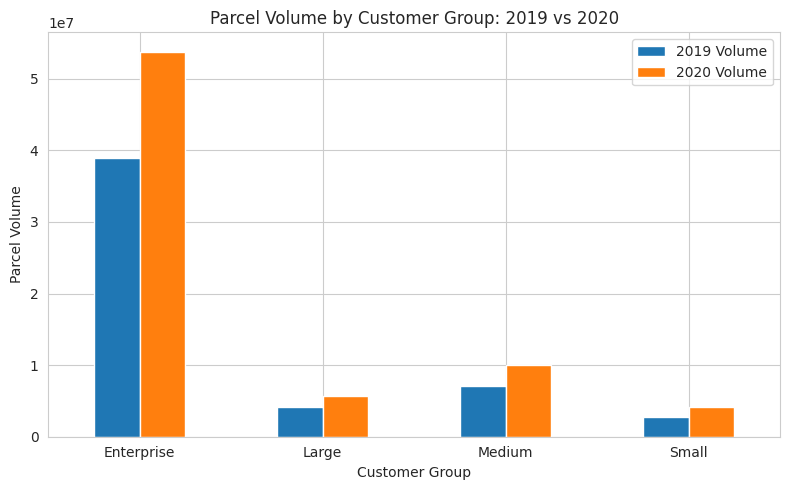

In [28]:
impact_group[['2019 Volume', '2020 Volume']].plot(kind='bar', figsize=(8,5))

plt.title('Parcel Volume by Customer Group: 2019 vs 2020')
plt.xlabel('Customer Group')
plt.ylabel('Parcel Volume')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#  revenue impact

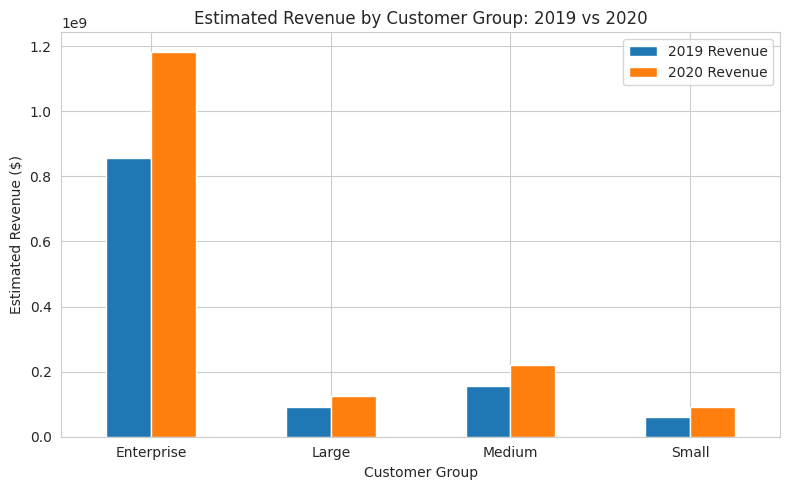

In [30]:
impact_group[['2019 Revenue', '2020 Revenue']].plot(kind='bar', figsize=(8,5))

plt.title('Estimated Revenue by Customer Group: 2019 vs 2020')
plt.xlabel('Customer Group')
plt.ylabel('Estimated Revenue ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Revenue increased across all customer groups in 2020, following the same pattern as parcel volume. Enterprise contributed the highest total revenue, while Medium and Small segments showed strong growth. This confirms that revenue growth was driven by increased shipment volume.

In [33]:
# EXPORT TABLES FOR EXCEL ANALYSIS

# Calculate growth from group_year_vol as pivot was not defined
growth_by_segment_df = group_year_vol.copy()
growth_by_segment_df['growth_%'] = ((growth_by_segment_df[2020] - growth_by_segment_df[2019]) / growth_by_segment_df[2019]) * 100

# Redefine rev_seg to ensure it's available in this cell
df['revenue'] = df['VOLUME'] * 22

# Ensure df has the 'Group' column for segmentation before groupby
df_with_group_for_revenue = df.merge(cust[['FakeCustomerID', 'Group']], on='FakeCustomerID', how='left')
rev_seg = df_with_group_for_revenue.groupby(['Group','THE_YEAR'])['revenue'].sum().unstack()

# Define cat_pct to ensure it's available in this cell
# FIX: 'Category' is not in cust, use 'Group' instead
cat_pct = cust['Group'].value_counts(normalize=True) * 100

# Define new_summary (using new_group from previous analysis)
new_summary = new_group # new_group is available from cell h0IW2u7ecmQS

# Define yearly_rev (total revenue per year)
yearly_rev = df.groupby('THE_YEAR')['revenue'].sum().reset_index()
yearly_rev.rename(columns={'revenue': 'Total_Revenue'}, inplace=True) # Rename for clarity

growth_by_segment_df.to_excel("1_growth_by_segment.xlsx")
rev_seg.to_excel("2_revenue_by_segment.xlsx")
new_summary.to_excel("3_new_customers.xlsx")
# FIX: 'Category' is not in cust, use 'Group' instead
cust['Group'].value_counts().to_excel("4_customer_classification.xlsx")
yearly_rev.to_excel("5_yearly_revenue.xlsx")
cat_pct.to_excel("6_customer_segments.xlsx")

print("Excel files exported successfully!")

Excel files exported successfully!


In [37]:
# Save customer summary for easy reference
cust.to_csv('customer_classification.csv', index=False)

### Conclusion

COVID-19 created a significant increase in parcel demand, with a clear impact beginning around Week 12 of 2020.

All customer segments experienced growth, with Enterprise driving the largest volume and smaller segments showing strong percentage increases. Growth was primarily driven by existing customers, with minimal churn and no new customer acquisition.

Overall, COVID led to sustained changes in customer behavior, presenting opportunities for long-term growth and improved capacity planning.